In [1]:
import json
import numpy as np
import pyvisa
import time
import hid # pip install hidapi
import skrf as rf
import matplotlib.pyplot as plt
import serial.tools.list_ports
from RsInstrument import RsInstrument, BinFloatFormat
from datetime import datetime
from pathlib import Path
import os
import sys
import matplotlib.colors as mcolors
from urllib.request import urlopen

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

yoko = None
for instrument in instruments:
    if 'YOKOGAWA' in instrument:
        # Initialize instrument
        yoko = rm.open_resource(instrument) 
        break

vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break
print(vna.query('*IDN?').strip())
vna.go_to_local()


PROGRAMMABLE_ATTENUATOR_IP_ADDRESS = '169.254.11.11'
def get_attenuation_state(ip_address):
    # The direct URL that successfully delivers the information
    url = f"http://{ip_address}/ATT?"
    
    try:
        with urlopen(url, timeout=2.0) as response:
            # Read bytes, decode to string, and remove whitespace/newlines
            attenuation_value = response.read().decode('utf-8').strip()
            return float(attenuation_value)
            
    except URLError as e:
        print(f"Connection failed: {e.reason}")
        return None
    except ValueError:
        print(f"Parsing Error: Could not convert response to number: {attenuation_value}")
        return None


Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30


107 seconds sweep time


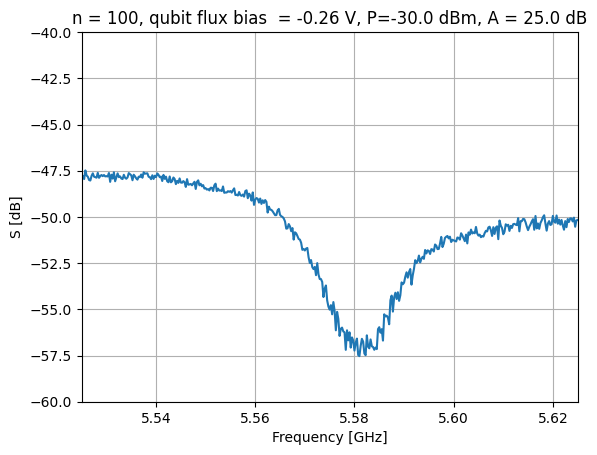

<Figure size 640x480 with 0 Axes>

In [35]:
number_of_averages = 100

try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)


vna_average = {}
vna_average['qubit_flux_bias'] = float(yoko.query(":SOUR:LEV?").strip())

now = datetime.now().astimezone()
vna_average['timestamp'] = int(now.timestamp())
vna_average['date'] = now.strftime("%d-%m-%Y")
vna_average['time'] = now.strftime("%H:%M:%S")
vna_average['timezone'] = now.tzname()
vna_average['temperature'] = '0.012'
vna_average['start_time'] = int(now.timestamp())
vna_average['programmable_attenuator'] = get_attenuation_state(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS)

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + qubit_flux_sweep['date'] + " Plots\n\n")

vna_state = {}
vna_state['idn'] = vna.query('*IDN?')
vna_state['fstart']    = float(vna.query(':SENS1:FREQ:START?'))
vna_state['fstop']     = float(vna.query(':SENS1:FREQ:STOP?'))
vna_state['numpoints'] = int(vna.query(':SENS1:SWEep:POINts?'))
vna_state['ifbw']      = float(vna.query(':SENS1:BAND?'))
vna_state['power']      = float(vna.query('SOURce1:POWer?'))
frequencies = np.linspace(vna_state['fstart'],vna_state['fstop'],vna_state['numpoints'])
fghz = frequencies/1e9
vna_average['fghz'] = fghz.tolist()
vna_average['vna'] = vna_state

vna_average['s_db'] = []
vna_average['s_deg'] = []

vna_average['number_of_averages'] = number_of_averages

for index in range(number_of_averages):
    print(f"count: {index}", end="\r", flush=True)    
    vna.bin_float_numbers_format = BinFloatFormat.Single_4bytes
    vna.write("FORM REAL,32") 
    vna.write_str(":CALC1:PAR:SEL 'Trc1'") 
    vna.write("INITiate:CONTinuous OFF")
    vna.write("INITiate:IMMediate")  
    opc_done = vna.query("*OPC?").strip()    
    if opc_done != "1":
        print(f"Error: OPC returned unexpected value '{opc_done}'; ending execution.")
        exit()
    raw_floats = vna.query_bin_or_ascii_float_list(":CALC1:DATA? SDAT")
    vna.write("INITiate:CONTinuous ON")
    vna.go_to_local()
    real_parts = np.array(raw_floats[0::2])
    imag_parts = np.array(raw_floats[1::2])
    complex_trace = real_parts + 1j * imag_parts
    s_matrix = np.zeros((len(frequencies), 1, 1), dtype=complex)
    s_matrix[:, 0, 0] = complex_trace
    trace_network = rf.Network(frequency=frequencies, s=s_matrix, name='data trace')
    vna_average['s_db'].append(trace_network.s_db[:,0,0])
    vna_average['s_deg'].append(trace_network.s_deg[:,0,0])
    time.sleep(0.05)

vna_average['s_db'] = np.array(vna_average['s_db'])
vna_average['s_deg'] = np.array(vna_average['s_deg'])

vna_average['s_db'] = vna_average['s_db'].tolist()
vna_average['s_deg'] = vna_average['s_deg'].tolist()

now = datetime.now().astimezone()
vna_average['finish_time'] = int(now.timestamp())
vna_average['sweep_time'] = vna_average['finish_time'] - vna_average['start_time']
print(str(vna_average['sweep_time']) + " seconds sweep time")

file_name = f"{vna_average['timestamp']}-vna-average.json"
file_path = target_dir / file_name

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(vna_average, f, indent=4)

vna_average['s_db'] = np.array(vna_average['s_db'])
vna_average['s_deg'] = np.array(vna_average['s_deg'])    


linear_traces = 10 ** (vna_average['s_db'] / 10)
linear_average = np.mean(linear_traces, axis=0)
db_average = 10 * np.log10(linear_average)

plt.plot(fghz,db_average)
plt.title('n = ' + str(number_of_averages) + ', qubit flux bias  = ' + str(vna_average['qubit_flux_bias']) + " V, P=" + str(vna_average['vna']['power']) + ' dBm, A = ' + str(vna_average['programmable_attenuator']) + ' dB')

plt.xlabel('Frequency [GHz]')
plt.ylabel('S [dB]')
plt.xlim([fghz[0],fghz[-1]])
plt.ylim([-60,-40])
plt.grid(True)

plot_file_name = f"{vna_average['timestamp']}-vna-average-plot.png"

plot_file_path = target_dir / plot_file_name
plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
plt.show()

with open(readme_path, "a") as file:
    file.write("![]("+ plot_file_name + ")\n")

with open(readme_path, "a") as file:
    file.write("\n### ![]("+ file_name + ")\n")

vna.go_to_local()


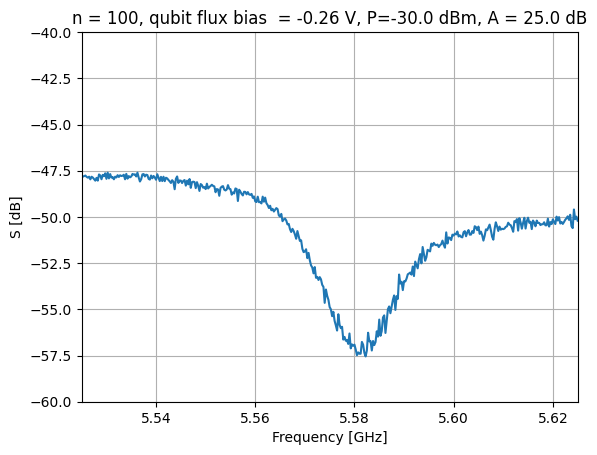

In [34]:
linear_traces = 10 ** (vna_average['s_db'] / 10)
linear_average = np.mean(linear_traces, axis=0)
db_average = 10 * np.log10(linear_average)

plt.plot(fghz,db_average)
plt.title('n = ' + str(number_of_averages) + ', qubit flux bias  = ' + str(vna_average['qubit_flux_bias']) + " V, P=" + str(vna_average['vna']['power']) + ' dBm, A = ' + str(vna_average['programmable_attenuator']) + ' dB')

plt.xlabel('Frequency [GHz]')
plt.ylabel('S [dB]')
plt.xlim([fghz[0],fghz[-1]])
plt.ylim([-60,-40])
plt.grid(True)
plt.show()

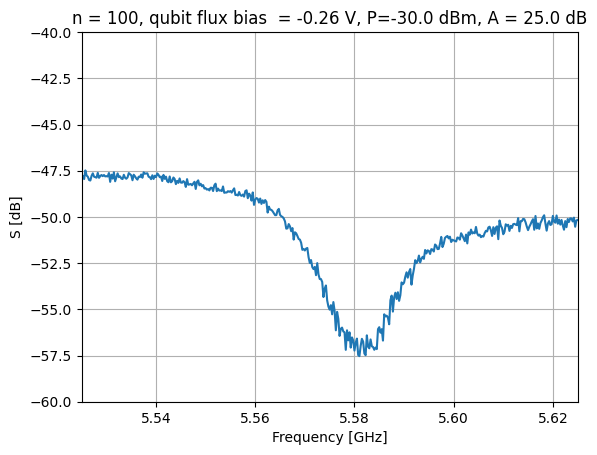

In [36]:
plt.plot(fghz,db_average)
plt.title('n = ' + str(number_of_averages) + ', qubit flux bias  = ' + str(vna_average['qubit_flux_bias']) + " V, P=" + str(vna_average['vna']['power']) + ' dBm, A = ' + str(vna_average['programmable_attenuator']) + ' dB')

plt.xlabel('Frequency [GHz]')
plt.ylabel('S [dB]')
plt.xlim([fghz[0],fghz[-1]])
plt.ylim([-60,-40])
plt.grid(True)

plot_file_name = f"{vna_average['timestamp']}-vna-average-plot.png"

plot_file_path = target_dir / plot_file_name
plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
plt.show()
